# Multimodal Skin Lesion Classification
## End-to-End Pipeline Demo

---

This notebook walks through the full pipeline built for **7-class skin lesion classification** using two complementary data modalities:

- **Dermoscopy images** — processed by convolutional neural networks (Stage 1)
- **Structured clinical metadata** — processed by gradient-boosted trees (Stage 2)

The pipeline then explores two strategies for combining these modalities:

- **Late fusion** (Stage 3): blend probability vectors from each modality
- **Early fusion** (Stage 4): concatenate handcrafted image features with metadata before training

Finally, **Stage 5** asks whether the merged feature space has any natural unsupervised structure aligned with disease labels.

### The 7 lesion classes

| Abbreviation | Full name |
|---|---|
| `ak` | Actinic Keratosis |
| `bcc` | Basal Cell Carcinoma |
| `benign_other` | Benign (other) |
| `melanoma` | Melanoma |
| `nevus` | Nevus |
| `scc` | Squamous Cell Carcinoma |
| `seborrheic_keratosis` | Seborrheic Keratosis |

### Pipeline overview

```
                ┌──────────────┐
Images ───────▶ │   CNN Model  │ ──▶ Probabilities ──┐
                └──────────────┘                     ├──▶ Late Fusion ─▶ Final Prediction
                ┌──────────────┐                     │
Metadata ─────▶ │ Tabular ML   │ ──▶ Probabilities ──┘
                └──────────────┘

Images ───────▶ Feature Extraction ─┐
                                    ├──▶ Early Fusion ─▶ Tabular Model ─▶ Prediction
Metadata ───────────────────────────┘
```

In [244]:
# Shared imports used throughout the notebook
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CLASS_NAMES = ["ak", "bcc", "benign_other", "melanoma", "nevus", "scc", "seborrheic_keratosis"]
CLASS_LABELS = ["AK", "BCC", "Benign\nOther", "Melanoma", "Nevus", "SCC", "Seb.\nKeratosis"]
PALETTE = plt.cm.tab10.colors

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Setup complete. ROOT:", ROOT)

Setup complete. ROOT: /Users/dimitriskaltsios/University/Individual/Kaltsios-Individual-Project


---
## Section 1 — Data Exploration

We work with a combined dataset that merges two public dermoscopy collections (MIDAS and PAD-UFES-20). Each sample has:
- a **dermoscopy image** (used by Stage 1 and Stage 4)
- **19 structured clinical features** (used by Stage 2 and Stage 4)

Data was standardised, de-duplicated at patient level, and stratified into **train / validation / test** splits.

In [245]:
# ── Load the combined Stage-2 CSV (metadata + labels) ─────────────────────────
train_df = pd.read_csv(ROOT / "Dataset" / "stage2_multiclass_train.csv")
val_df   = pd.read_csv(ROOT / "Dataset" / "stage2_multiclass_val.csv")
test_df  = pd.read_csv(ROOT / "Dataset" / "stage2_multiclass_test.csv")

print(f"Train: {len(train_df):,} samples")
print(f"Val:   {len(val_df):,} samples")
print(f"Test:  {len(test_df):,} samples")
print(f"Total: {len(train_df) + len(val_df) + len(test_df):,} samples")
train_df.head(3)

Train: 3,977 samples
Val:   853 samples
Test:  818 samples
Total: 5,648 samples


,sample_id,y,dataset_id,patient_global,age,sex,fitzpatrick,lesion_size_mm,diameter_2,anatomical_site_clean,...,elevation,smoking,alcohol_consumption,cancer_history,skin_cancer_history,pesticide,has_piped_water,has_sewage_system,subtype,y_class
0,A_A_PAT_46_1,1.0,A,A_PAT_46,55,female,3,6.0,5.0,neck,...,true,false,false,true,true,false,true,true,bcc,1
1,A_A_PAT_1545_2,1.0,A,A_PAT_1545,77,unknown,0,-1.0,-1.0,face,...,false,unknown,unknown,unknown,unknown,unknown,unknown,unknown,ak,0
2,A_A_PAT_1989_3,1.0,A,A_PAT_1989,75,unknown,0,-1.0,-1.0,hand,...,false,unknown,unknown,unknown,unknown,unknown,unknown,unknown,ak,0


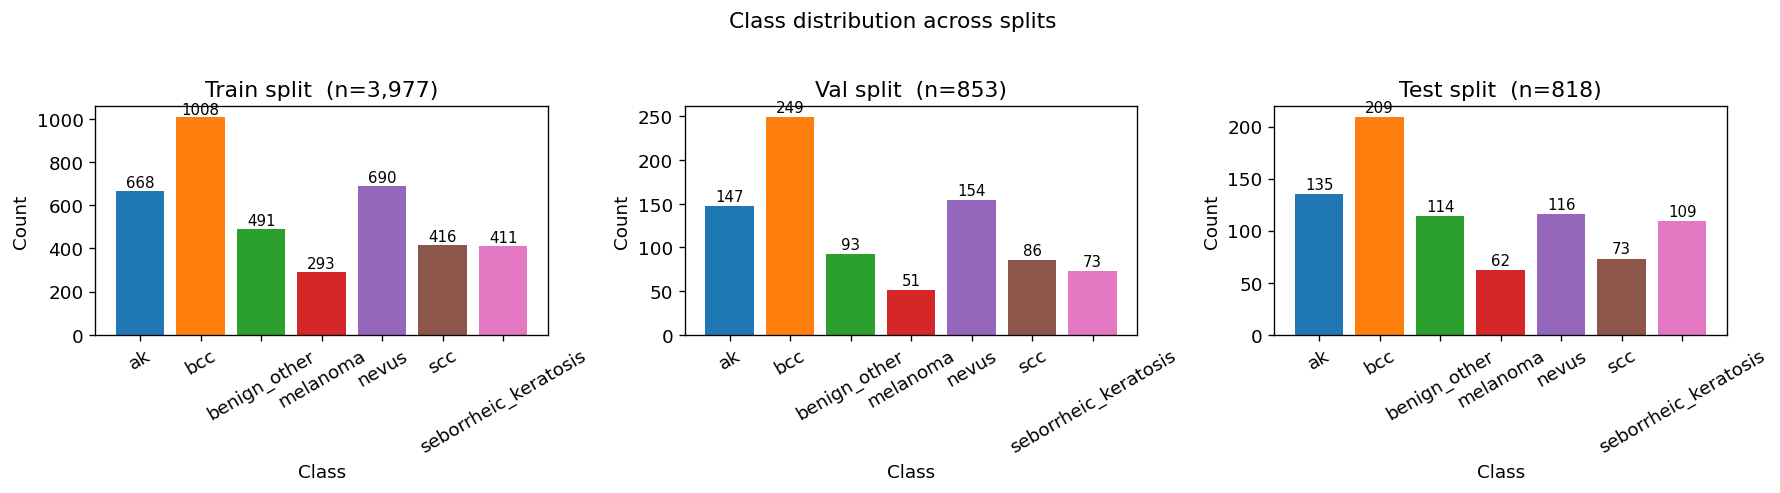

In [246]:
# ── Class distribution — visualise imbalance ──────────────────────────────────
label_col = "y_class"

# Load the label mapping
with open(ROOT / "Dataset" / "label_mapping_multiclass.json") as f:
    label_map = json.load(f)

# index_to_class has string keys ("0"→"ak"), y_class column is int → cast to str when looking up
int_to_name = {int(k): v for k, v in label_map["index_to_class"].items()}

splits = {"Train": train_df, "Val": val_df, "Test": test_df}
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (split_name, df) in zip(axes, splits.items()):
    counts = df[label_col].value_counts().sort_index()
    names  = [int_to_name.get(i, str(i)) for i in counts.index]
    bars   = ax.bar(names, counts.values, color=PALETTE[:len(names)])
    ax.set_title(f"{split_name} split  (n={len(df):,})")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(val), ha="center", va="bottom", fontsize=9)

plt.suptitle("Class distribution across splits", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [247]:
# ── Clinical feature overview ──────────────────────────────────────────────────
with open(ROOT / "Dataset" / "schema.json") as f:
    schema = json.load(f)

features = schema["stage2_features"]
print(f"{len(features)} clinical features used in Stage 2 and Stage 4:\n")

numeric_feats   = [c for c in features if train_df[c].dtype != object]
categorical_feats = [c for c in features if train_df[c].dtype == object]

print("Numeric features:", numeric_feats)
print("Categorical features:", categorical_feats)
print()
train_df[features].describe(include="all").T[["count", "mean", "std", "min", "max", "top", "freq"]].fillna("-")

19 clinical features used in Stage 2 and Stage 4:

Numeric features: ['age', 'fitzpatrick', 'lesion_size_mm', 'diameter_2']
Categorical features: ['sex', 'anatomical_site_clean', 'bleed', 'hurt', 'itch', 'changed', 'grew', 'elevation', 'smoking', 'alcohol_consumption', 'cancer_history', 'skin_cancer_history', 'pesticide', 'has_piped_water', 'has_sewage_system']



,count,mean,std,min,max,top,freq
age,3977.0,61.870757,16.077087,8.0,99.0,-,-
sex,3977.0,-,-,-,-,male,2076
fitzpatrick,3977.0,1.878049,0.978883,0.0,6.0,-,-
lesion_size_mm,3977.0,6.793601,6.996409,-1.0,100.0,-,-
diameter_2,3977.0,1.568066,5.347381,-1.0,70.0,-,-
anatomical_site_clean,3977.0,-,-,-,-,face,374
bleed,3977.0,-,-,-,-,unknown,2378
hurt,3977.0,-,-,-,-,unknown,2378
itch,3977.0,-,-,-,-,unknown,2378
changed,3977.0,-,-,-,-,unknown,2378


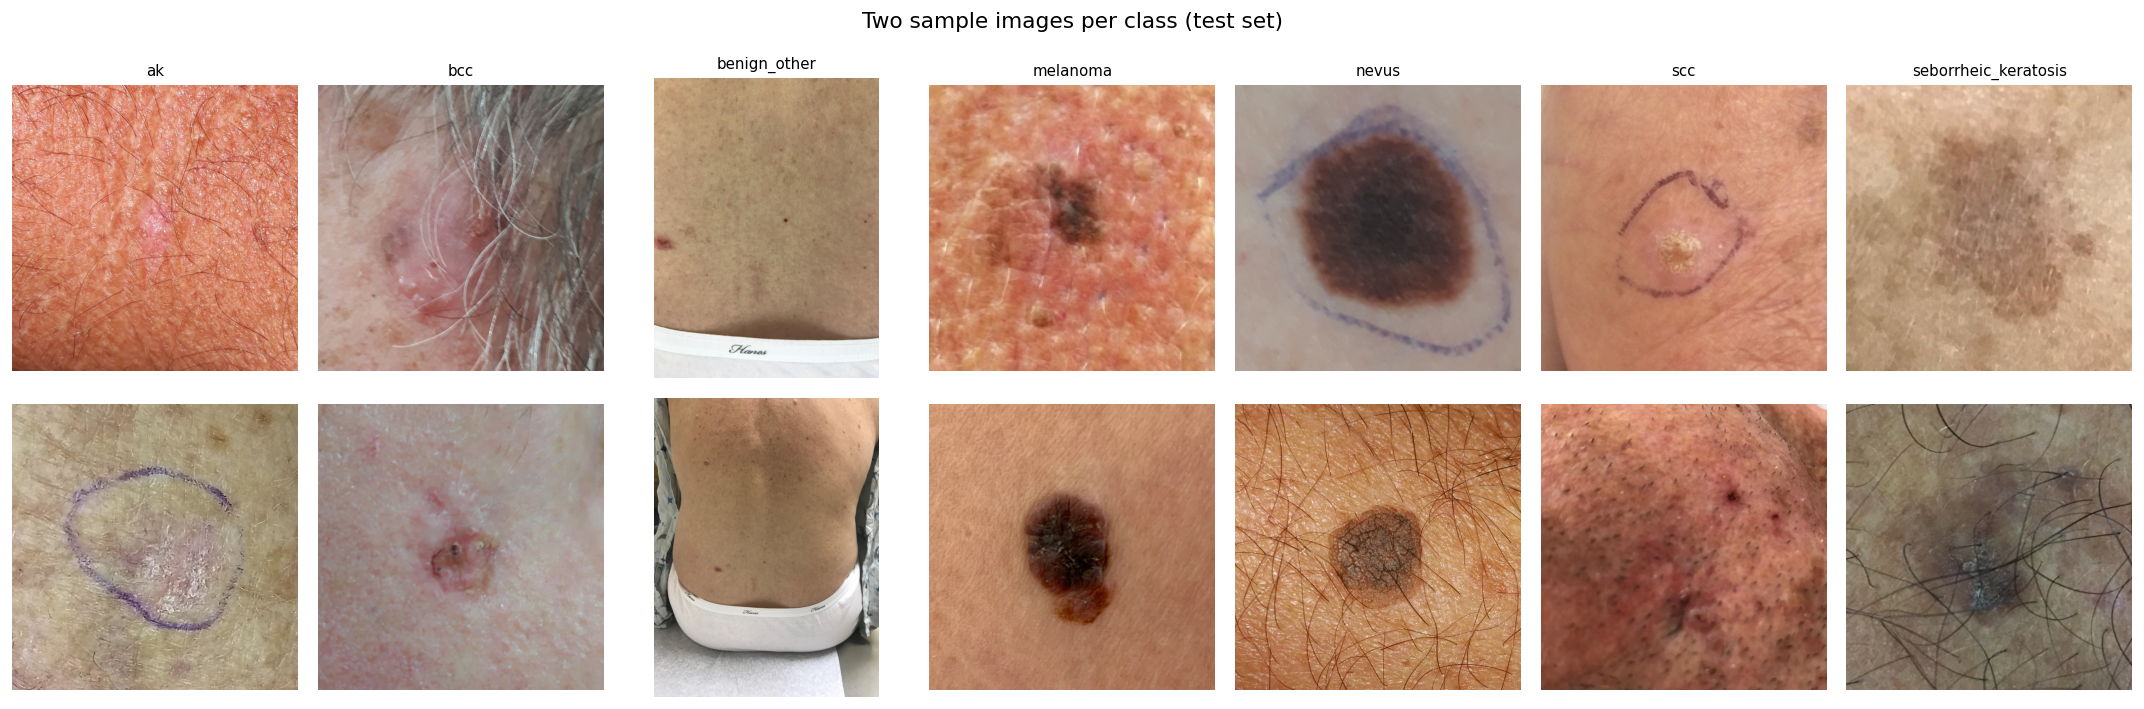

In [248]:
m# ── Sample images from the test set ───────────────────────────────────────────i
from PIL import Image

stage1_test = pd.read_csv(ROOT / "Dataset" / "stage1_multiclass_test.csv")
stage1_test["class_name"] = stage1_test[label_col].map(int_to_name)

fig, axes = plt.subplots(2, 7, figsize=(18, 6))
for col_idx, cls in enumerate(CLASS_NAMES):
    subset = stage1_test[stage1_test["class_name"] == cls]
    for row_idx in range(2):
        ax = axes[row_idx, col_idx]
        ax.axis("off")
        if row_idx < len(subset):
            img_path = ROOT / subset.iloc[row_idx]["image_path"]
            if img_path.exists():
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, "image\nnot found", ha="center", va="center",
                        transform=ax.transAxes, fontsize=8, color="grey")
        if row_idx == 0:
            ax.set_title(cls, fontsize=9)

plt.suptitle("Two sample images per class (test set)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 2 — Stage 1: Image-Based CNNs

This section is in **two parts**:

1. **2.1 Baseline** — original Stage 1 setup (standard train-time augmentation, inverse-frequency loss weights), with **CV**, **test metrics**, **per-class F1**, **confusion matrix**, and **Grad-CAM** for baseline checkpoints only.
2. **2.2 Augmented runs** — follow-up experiments with **stronger augmentation**, **weighted sampling**, and (in v2) **cosine LR** and more epochs; a **test-set comparison** vs baseline appears at the end of Section 2.

### 2.1 Baseline implementation

Two ImageNet-pretrained backbones were fine-tuned on the dermoscopy images:
- **EfficientNet-B0** — compact, mobile-friendly
- **ResNet-50** — classic residual network

Both were trained with **inverse-frequency class weights** in the cross-entropy loss to combat class imbalance.

**Baseline training augmentations** (train split only):

| Transform | Value |
|---|---|
| Resize | 224 x 224 |
| Random horizontal flip | yes |
| Random vertical flip | yes |
| Random rotation | +/- 180 degrees |
| Colour jitter (brightness, contrast, saturation) | +/- 0.2 |
| Normalise | ImageNet mean / std |

Checkpoint folders: `efficientnet_b0_multiclass` and `resnet50_multiclass` under `Stage1/checkpoints/`.

The code cells until **2.2** use **baseline models only**.


In [249]:
# --- 2.1 Baseline: 5-fold cross-validation (EfficientNet-B0, ResNet-50 only) ---
# ── Load 5-fold CV results ─────────────────────────────────────────────────────
def load_cv(path):
    with open(path) as f:
        return json.load(f)

eff_cv  = load_cv(ROOT / "Stage1" / "cv_results" / "efficientnet_b0_multiclass_cv.json")
res_cv  = load_cv(ROOT / "Stage1" / "cv_results" / "resnet50_multiclass_cv.json")

def cv_row(cv_data, label):
    ms = cv_data["metrics_mean_std"]
    return {
        "Model": label,
        "Accuracy":     f"{ms['acc']['mean']:.3f} ± {ms['acc']['std']:.3f}",
        "Macro F1":     f"{ms['f1_macro']['mean']:.3f} ± {ms['f1_macro']['std']:.3f}",
        "Macro ROC AUC": f"{ms['roc_auc_macro']['mean']:.3f} ± {ms['roc_auc_macro']['std']:.3f}",
        "Macro PR AUC": f"{ms['pr_auc_macro']['mean']:.3f} ± {ms['pr_auc_macro']['std']:.3f}",
    }

cv_table = pd.DataFrame([cv_row(eff_cv, "EfficientNet-B0"), cv_row(res_cv, "ResNet-50")])
cv_table.set_index("Model", inplace=True)
print("Stage 1 — 5-fold cross-validation (mean ± std on validation folds)")
cv_table

Stage 1 — 5-fold cross-validation (mean ± std on validation folds)


,Accuracy,Macro F1,Macro ROC AUC,Macro PR AUC
Model,,,,
EfficientNet-B0,0.486 ± 0.009,0.459 ± 0.011,0.831 ± 0.009,0.481 ± 0.022
ResNet-50,0.486 ± 0.009,0.459 ± 0.011,0.831 ± 0.009,0.481 ± 0.022


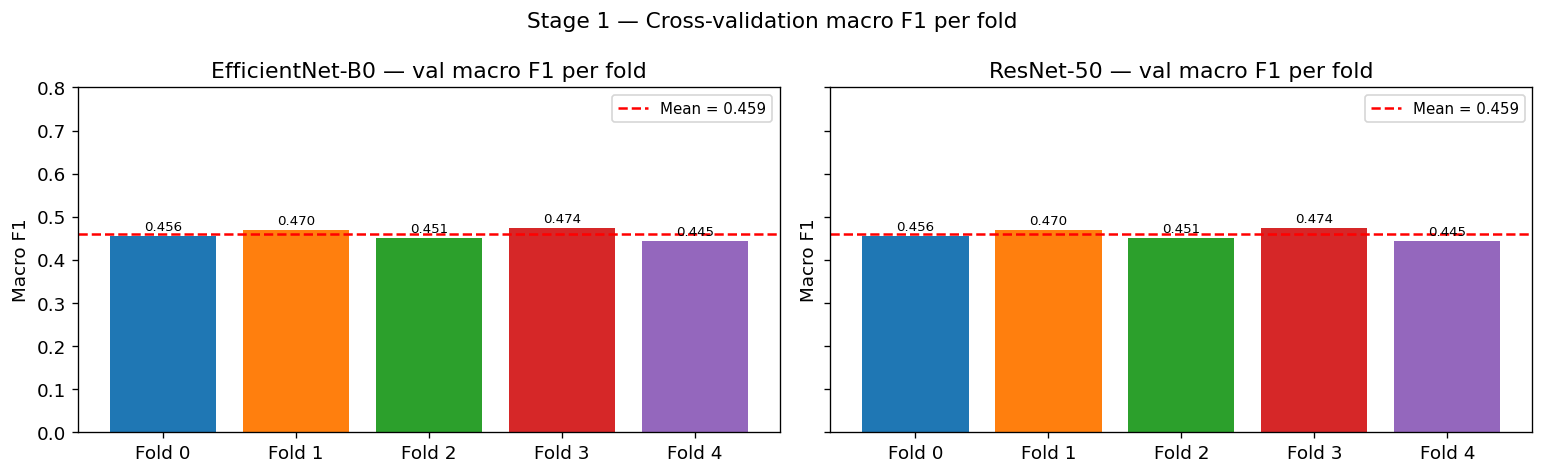

In [250]:
# ── Per-fold accuracy bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
metrics_key = "f1_macro"

for ax, (cv_data, model_label) in zip(axes, [(eff_cv, "EfficientNet-B0"), (res_cv, "ResNet-50")]):
    fold_vals = [f["best_val_metrics"][metrics_key] for f in cv_data["folds"]]
    bars = ax.bar([f"Fold {i}" for i in range(len(fold_vals))], fold_vals, color=PALETTE[:len(fold_vals)])
    mean_val = np.mean(fold_vals)
    ax.axhline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean = {mean_val:.3f}")
    ax.set_title(f"{model_label} — val macro F1 per fold")
    ax.set_ylim(0, 0.8)
    ax.set_ylabel("Macro F1")
    ax.legend(fontsize=9)
    for bar, val in zip(bars, fold_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Stage 1 — Cross-validation macro F1 per fold", fontsize=13)
plt.tight_layout()
plt.show()

In [251]:
# ── Test metrics — load from checkpoint or fall back to overview.md values ────
# These are the test-set results reported in overview.md §9.1
S1_TEST = {
    "EfficientNet-B0": {"acc": 0.487, "f1_macro": 0.464, "roc_auc_macro": 0.848, "pr_auc_macro": 0.503,
                        "per_class_f1": {"ak": 0.658, "bcc": 0.564, "benign_other": 0.358,
                                         "melanoma": 0.327, "nevus": 0.453, "scc": 0.398,
                                         "seborrheic_keratosis": 0.489}},
    "ResNet-50":       {"acc": 0.477, "f1_macro": 0.457, "roc_auc_macro": 0.835, "pr_auc_macro": 0.467,
                        "per_class_f1": {}},
}

# Try to load from checkpoint if available
for model, ckpt_name in [("EfficientNet-B0", "efficientnet_b0_multiclass"), ("ResNet-50", "resnet50_multiclass")]:
    p = ROOT / "Stage1" / "checkpoints" / ckpt_name / "test_metrics.json"
    if p.exists():
        with open(p) as f:
            S1_TEST[model] = json.load(f)
        print(f"Loaded live checkpoint for {model}")
    else:
        print(f"Using pre-recorded results for {model} (checkpoint not found at {p})")

# Summary table
rows = []
for model, m in S1_TEST.items():
    rows.append({"Model": model, "Accuracy": m["acc"], "Macro F1": m["f1_macro"],
                 "Macro ROC AUC": m["roc_auc_macro"], "Macro PR AUC": m["pr_auc_macro"]})
pd.DataFrame(rows).set_index("Model").round(3)

Loaded live checkpoint for EfficientNet-B0
Loaded live checkpoint for ResNet-50


,Accuracy,Macro F1,Macro ROC AUC,Macro PR AUC
Model,,,,
EfficientNet-B0,0.487,0.464,0.848,0.503
ResNet-50,0.477,0.457,0.835,0.467


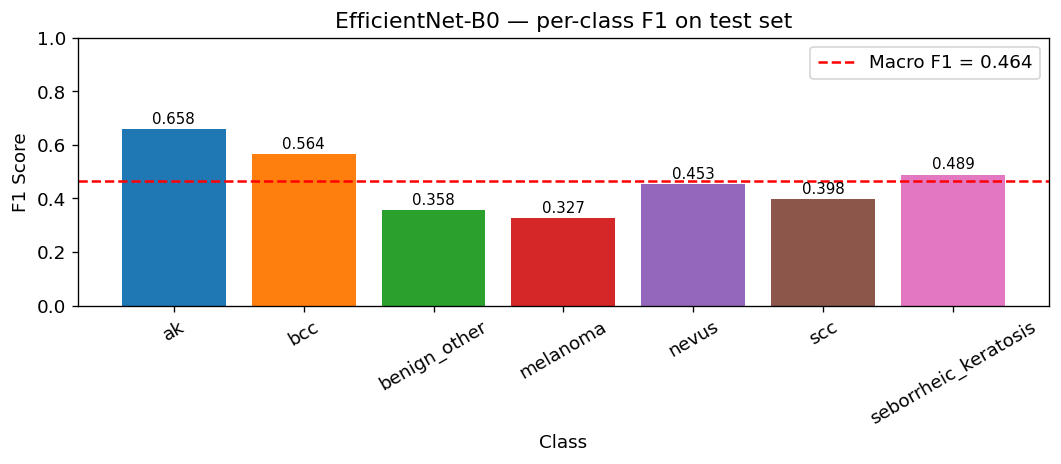

Hardest classes: melanoma and benign_other — high intra-class variability and overlap.


In [252]:
# ── Per-class F1 bar chart (EfficientNet-B0) ───────────────────────────────────
# Checkpoints store per-class data under "per_class" (each value is a dict with "f1");
# the hardcoded fallback uses "per_class_f1" (each value is already a float).
eff_data = S1_TEST["EfficientNet-B0"]
if "per_class" in eff_data:
    per_class_f1 = {cls: vals["f1"] for cls, vals in eff_data["per_class"].items()}
else:
    per_class_f1 = eff_data.get("per_class_f1", {})
if per_class_f1:
    classes = list(per_class_f1.keys())
    f1_vals  = list(per_class_f1.values())

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(classes, f1_vals, color=PALETTE[:len(classes)])
    ax.axhline(np.mean(f1_vals), color="red", linestyle="--", linewidth=1.5,
               label=f"Macro F1 = {np.mean(f1_vals):.3f}")
    ax.set_xlabel("Class")
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 1)
    ax.set_title("EfficientNet-B0 — per-class F1 on test set")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()
    print("Hardest classes: melanoma and benign_other — high intra-class variability and overlap.")

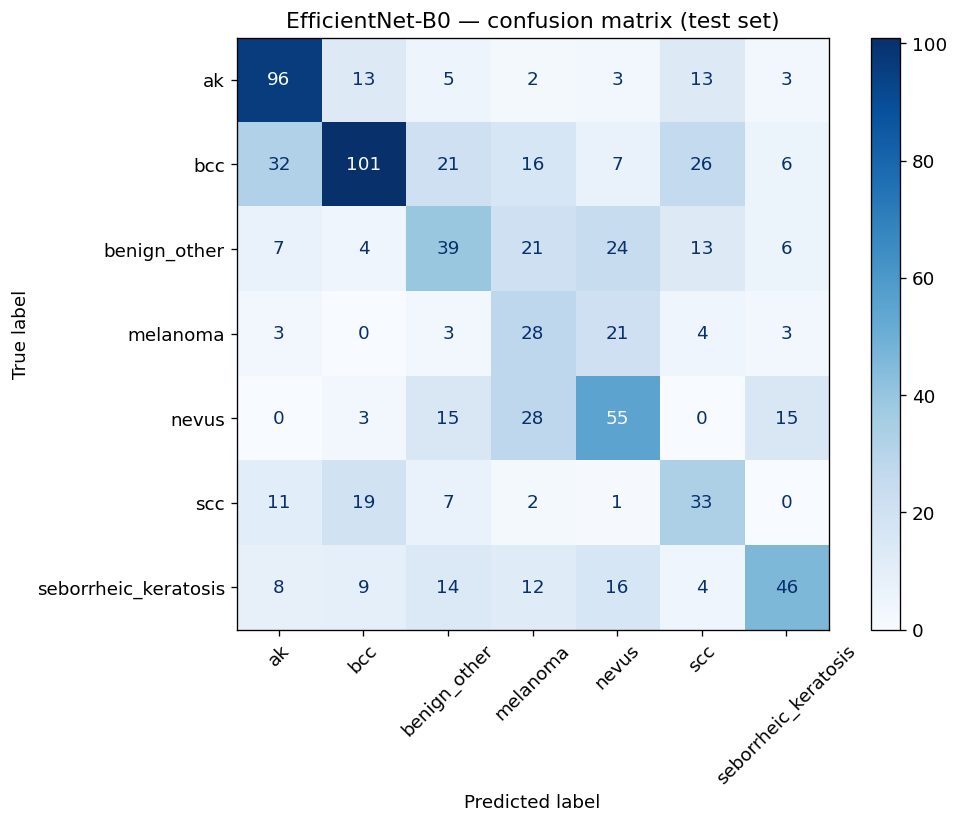

In [253]:
# ── Confusion matrix ──────────
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

pred_path = ROOT / "Stage1" / "checkpoints" / "efficientnet_b0_multiclass" / "test_predictions.csv"
if pred_path.exists():
    preds = pd.read_csv(pred_path)
    cm = confusion_matrix(preds["y_true"], preds["y_pred"])
    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
    ax.set_title("EfficientNet-B0 — confusion matrix (test set)")
    plt.tight_layout()
    plt.show()
else:
    print(f"Prediction file not found at:\n  {pred_path}\n"
          "Train the model first: python Stage1/train.py Stage1/configs/efficientnet_b0_multiclass.yaml")

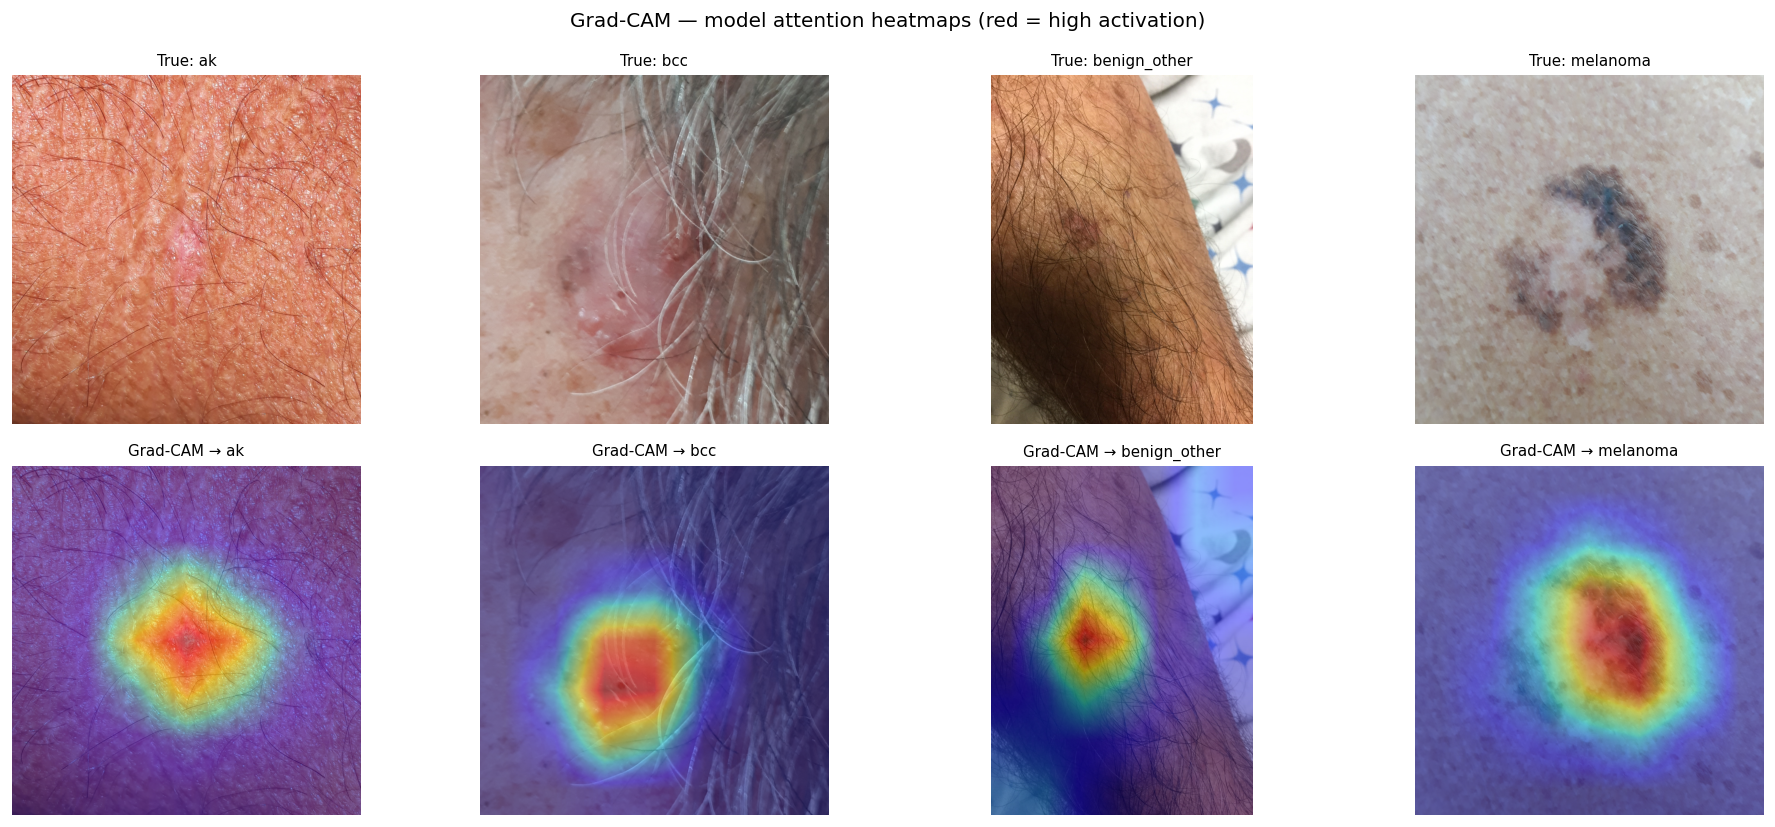

In [254]:
# ── Grad-CAM visualisation ─────────────────────
from io import BytesIO

ckpt_pt = ROOT / "Stage1" / "checkpoints" / "efficientnet_b0_multiclass" / "best.pt"

if ckpt_pt.exists() and pred_path.exists():
    from demo.predict import load_cnn, grad_cam, overlay_heatmap, predict_cnn

    model_bundle = load_cnn("efficientnet_b0", str(ckpt_pt), img_size=224)
    preds        = pd.read_csv(pred_path)

    # Pick one correct prediction per class (up to 4 classes for display)
    shown = []
    for cls_idx, cls_name in enumerate(CLASS_NAMES[:4]):
        subset = preds[(preds["y_true"] == cls_idx) & (preds["y_pred"] == cls_idx)]
        if len(subset) == 0:
            continue
        row = subset.iloc[0]
        img_row = stage1_test[stage1_test["sample_id"] == row["sample_id"]]
        if len(img_row) == 0:
            continue
        img_path = ROOT / img_row.iloc[0]["image_path"]
        if img_path.exists():
            shown.append((cls_name, img_path))

    if shown:
        fig, axes = plt.subplots(2, len(shown), figsize=(4 * len(shown), 7))
        for col, (cls_name, img_path) in enumerate(shown):
            with open(img_path, "rb") as f:
                raw = f.read()
            cam, orig_img, pred_idx = grad_cam(model_bundle, BytesIO(raw))
            overlay = overlay_heatmap(cam, orig_img)
            axes[0, col].imshow(orig_img)
            axes[0, col].axis("off")
            axes[0, col].set_title(f"True: {cls_name}", fontsize=9)
            axes[1, col].imshow(overlay)
            axes[1, col].axis("off")
            axes[1, col].set_title(f"Grad-CAM → {CLASS_NAMES[pred_idx]}", fontsize=9)
        plt.suptitle("Grad-CAM — model attention heatmaps (red = high activation)",
                     fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("No matching image paths found for Grad-CAM display.")
else:
    print("Grad-CAM requires both the trained checkpoint (best.pt) and test_predictions.csv.")
    print(f"Expected checkpoint: {ckpt_pt}")

### 2.2 Augmented training (comparison)

These runs use separate configs (e.g. `Stage1/configs/*multiclass_aug*.yaml`): **random resized crop**, **stronger colour jitter**, **random erasing**, and a **weighted random sampler** (hard `1/n` in v1, softer `1/sqrt(n)` in v2). **v2** also adds a **cosine annealing** learning-rate schedule and **more epochs**. Implementation details: `Stage1/data/dataset.py`, `Stage1/train.py`.

The table below merges **baseline** test metrics (from `S1_TEST` above) with **augmented** checkpoints when `test_metrics.json` exists. If a row is missing, run training and `Stage1/eval.py` for that checkpoint.


In [255]:
# --- 2.2 Augmented models: test-set comparison vs baseline --------------------------------
from IPython.display import display

def _load_s1_test(path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)

aug_ckpts = {
    "EfficientNet-B0 + aug (v1)":  "efficientnet_b0_multiclass_aug",
    "ResNet-50 + aug (v1)":        "resnet50_multiclass_aug",
    "EfficientNet-B0 + aug (v2)":  "efficientnet_b0_multiclass_aug_v2",
    "ResNet-50 + aug (v2)":        "resnet50_multiclass_aug_v2",
}

base_rows = []
for model, m in S1_TEST.items():
    base_rows.append({
        "Model": f"{model} (baseline)",
        "Accuracy": round(m["acc"], 3),
        "Macro F1": round(m["f1_macro"], 3),
        "Macro ROC AUC": round(m["roc_auc_macro"], 3),
        "Macro PR AUC": round(m["pr_auc_macro"], 3),
    })

aug_rows = []
for label, sub in aug_ckpts.items():
    mp = ROOT / "Stage1" / "checkpoints" / sub / "test_metrics.json"
    m = _load_s1_test(mp)
    if m is None:
        print(f"[missing] {label}: {mp}")
        continue
    aug_rows.append({
        "Model": label,
        "Accuracy": round(m["acc"], 3),
        "Macro F1": round(m["f1_macro"], 3),
        "Macro ROC AUC": round(m["roc_auc_macro"], 3),
        "Macro PR AUC": round(m["pr_auc_macro"], 3),
    })

if aug_rows:
    print(f"Test-set summary: {len(base_rows)} baseline + {len(aug_rows)} augmented models.")
    print()
    combo = pd.DataFrame(base_rows + aug_rows).set_index("Model")
    display(combo)
else:
    print("No augmented test_metrics.json found. After training, run Stage1/eval.py with --ckpt best.pt for each augmented run.")


Test-set summary: 2 baseline + 4 augmented models.



,Accuracy,Macro F1,Macro ROC AUC,Macro PR AUC
Model,,,,
EfficientNet-B0 (baseline),0.487,0.464,0.848,0.503
ResNet-50 (baseline),0.477,0.457,0.835,0.467
EfficientNet-B0 + aug (v1),0.432,0.434,0.829,0.473
ResNet-50 + aug (v1),0.477,0.466,0.846,0.503
EfficientNet-B0 + aug (v2),0.480,0.464,0.843,0.507
ResNet-50 + aug (v2),0.502,0.471,0.828,0.493


---
## Section 3 — Stage 2: Metadata-Based Tabular Models

Stage 2 uses the **19 structured clinical features** without any image information.

### Preprocessing (`Stage2/data/preprocess.py`)

| Feature type | Treatment |
|---|---|
| Categorical (`sex`, `anatomical_site_clean`) | One-hot encoding |
| Numeric (age, lesion sizes, binary symptoms) | StandardScaler |

### Models
- **XGBoost** — gradient boosted trees with `softmax` objective
- **Random Forest** — ensemble of decision trees via `sklearn`

Both use **5-fold CV** for model selection and a separate **grid search** for hyperparameter tuning.

In [256]:
# ── Stage 2 CV results ─────────────────────────────────────────────────────────
xgb_cv = load_cv(ROOT / "Stage2" / "cv_results" / "xgboost_multiclass_cv.json")
rf_cv  = load_cv(ROOT / "Stage2" / "cv_results" / "random_forest_multiclass_cv.json")

def cv_row_s2(cv_data, label):
    ms = cv_data["metrics_mean_std"]
    return {
        "Model": label,
        "Accuracy":      f"{ms['acc']['mean']:.3f} ± {ms['acc']['std']:.3f}",
        "Macro F1":      f"{ms['f1_macro']['mean']:.3f} ± {ms['f1_macro']['std']:.3f}",
        "Macro ROC AUC": f"{ms['roc_auc_macro']['mean']:.3f} ± {ms['roc_auc_macro']['std']:.3f}",
        "Macro PR AUC":  f"{ms['pr_auc_macro']['mean']:.3f} ± {ms['pr_auc_macro']['std']:.3f}",
    }

cv_s2 = pd.DataFrame([cv_row_s2(xgb_cv, "XGBoost"), cv_row_s2(rf_cv, "Random Forest")])
cv_s2.set_index("Model", inplace=True)
print("Stage 2 — 5-fold CV (mean ± std)")
cv_s2

Stage 2 — 5-fold CV (mean ± std)


,Accuracy,Macro F1,Macro ROC AUC,Macro PR AUC
Model,,,,
XGBoost,0.472 ± 0.025,0.396 ± 0.019,0.806 ± 0.011,0.459 ± 0.016
Random Forest,0.467 ± 0.015,0.382 ± 0.013,0.791 ± 0.009,0.428 ± 0.006


In [257]:
# ── Grid search best configs ────────────────────────────────────────────────────
xgb_grid = load_cv(ROOT / "Stage2" / "cv_results" / "xgboost_multiclass_grid.json")
rf_grid  = load_cv(ROOT / "Stage2" / "cv_results" / "random_forest_multiclass_grid.json")

def best_grid_row(grid_data, label):
    best = grid_data["best"]
    ms   = best["metrics_mean_std"]
    params = best.get("params", best.get("best_params", {}))
    return {
        "Model":          label,
        "Best Macro F1":  f"{ms['f1_macro']['mean']:.3f} ± {ms['f1_macro']['std']:.3f}",
        "Best ROC AUC":   f"{ms['roc_auc_macro']['mean']:.3f} ± {ms['roc_auc_macro']['std']:.3f}",
        "Key hyperparameters": str({k: v for k, v in list(params.items())[:4]}),
    }

grid_table = pd.DataFrame([best_grid_row(xgb_grid, "XGBoost"), best_grid_row(rf_grid, "Random Forest")])
grid_table.set_index("Model", inplace=True)
print("Stage 2 — Grid search best configurations (5-fold CV, objective = macro F1)")
grid_table

Stage 2 — Grid search best configurations (5-fold CV, objective = macro F1)


,Best Macro F1,Best ROC AUC,Key hyperparameters
Model,,,
XGBoost,0.404 ± 0.021,0.811 ± 0.010,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
Random Forest,0.414 ± 0.020,0.798 ± 0.008,"{'max_depth': 10, 'max_features': 0.5, 'min_sa..."


In [258]:
# ── Test metrics ──────────────────────────────────────
S2_TEST = {
    "XGBoost":       {"acc": 0.474, "f1_macro": 0.403, "roc_auc_macro": 0.817, "pr_auc_macro": 0.476},
    "Random Forest": {"acc": 0.462, "f1_macro": 0.388, "roc_auc_macro": 0.802, "pr_auc_macro": 0.448},
}

for model, ckpt_name in [("XGBoost", "xgboost_multiclass"), ("Random Forest", "random_forest_multiclass")]:
    p = ROOT / "Stage2" / "checkpoints" / ckpt_name / "test_metrics.json"
    if p.exists():
        with open(p) as f:
            S2_TEST[model] = json.load(f)
        print(f"Loaded live checkpoint for {model}")
    else:
        print(f"Using pre-recorded results for {model}")

rows = []
for model, m in S2_TEST.items():
    rows.append({"Model": model, "Accuracy": m["acc"], "Macro F1": m["f1_macro"],
                 "Macro ROC AUC": m["roc_auc_macro"], "Macro PR AUC": m["pr_auc_macro"]})
pd.DataFrame(rows).set_index("Model").round(3)

Loaded live checkpoint for XGBoost
Loaded live checkpoint for Random Forest


,Accuracy,Macro F1,Macro ROC AUC,Macro PR AUC
Model,,,,
XGBoost,0.474,0.403,0.817,0.476
Random Forest,0.462,0.388,0.802,0.448


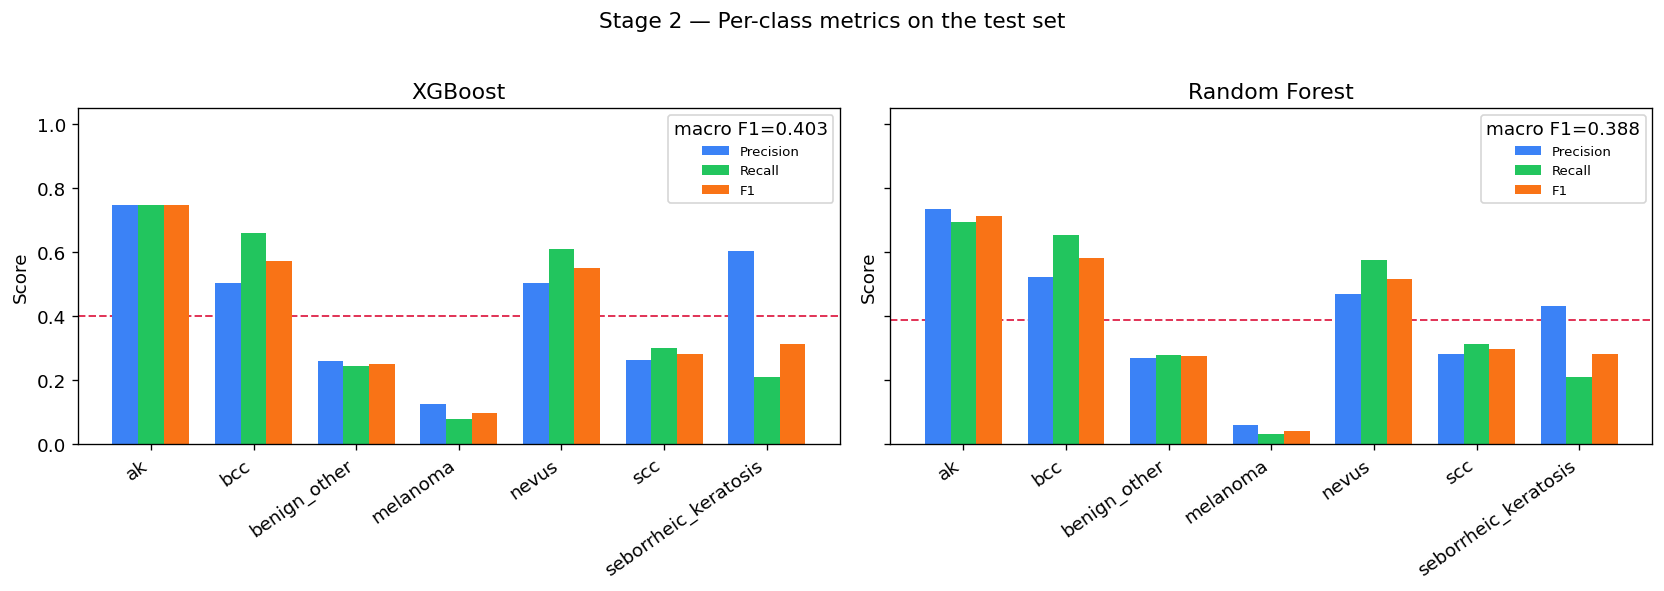

In [259]:
# --- Stage 2: per-class precision / recall / F1 (test set) ----------------------------
# Uses `S2_TEST` when it contains `per_class`; otherwise reads `test_metrics.json` from checkpoints.

def _stage2_metrics_with_per_class(model_name, ckpt_subdir):
    m = S2_TEST.get(model_name, {})
    if isinstance(m, dict) and "per_class" in m:
        return m
    path = ROOT / "Stage2" / "checkpoints" / ckpt_subdir / "test_metrics.json"
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None


def _plot_per_class_p_r_f1(ax, metrics, title):
    if not metrics or "per_class" not in metrics:
        ax.text(
            0.5, 0.5, "No per-class metrics available\n(run Stage 2 eval or load test_metrics.json)",
            ha="center", va="center", transform=ax.transAxes, fontsize=10, color="gray",
        )
        ax.set_axis_off()
        ax.set_title(title)
        return
    pc = metrics["per_class"]
    labels = [c for c in CLASS_NAMES if c in pc]
    if not labels:
        labels = list(pc.keys())
    x = np.arange(len(labels))
    width = 0.25
    prec = [float(pc[c]["precision"]) for c in labels]
    rec = [float(pc[c]["recall"]) for c in labels]
    f1 = [float(pc[c]["f1"]) for c in labels]
    ax.bar(x - width, prec, width, label="Precision", color="#3b82f6")
    ax.bar(x, rec, width, label="Recall", color="#22c55e")
    ax.bar(x + width, f1, width, label="F1", color="#f97316")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(title)
    mf = float(metrics.get("f1_macro", float("nan")))
    ax.axhline(mf, color="crimson", linestyle="--", linewidth=1.2, alpha=0.85, zorder=0)
    ax.legend(loc="upper right", fontsize=8, title=f"macro F1={mf:.3f}")


xgb_m = _stage2_metrics_with_per_class("XGBoost", "xgboost_multiclass")
rf_m = _stage2_metrics_with_per_class("Random Forest", "random_forest_multiclass")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
_plot_per_class_p_r_f1(axes[0], xgb_m, "XGBoost")
_plot_per_class_p_r_f1(axes[1], rf_m, "Random Forest")
fig.suptitle("Stage 2 — Per-class metrics on the test set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


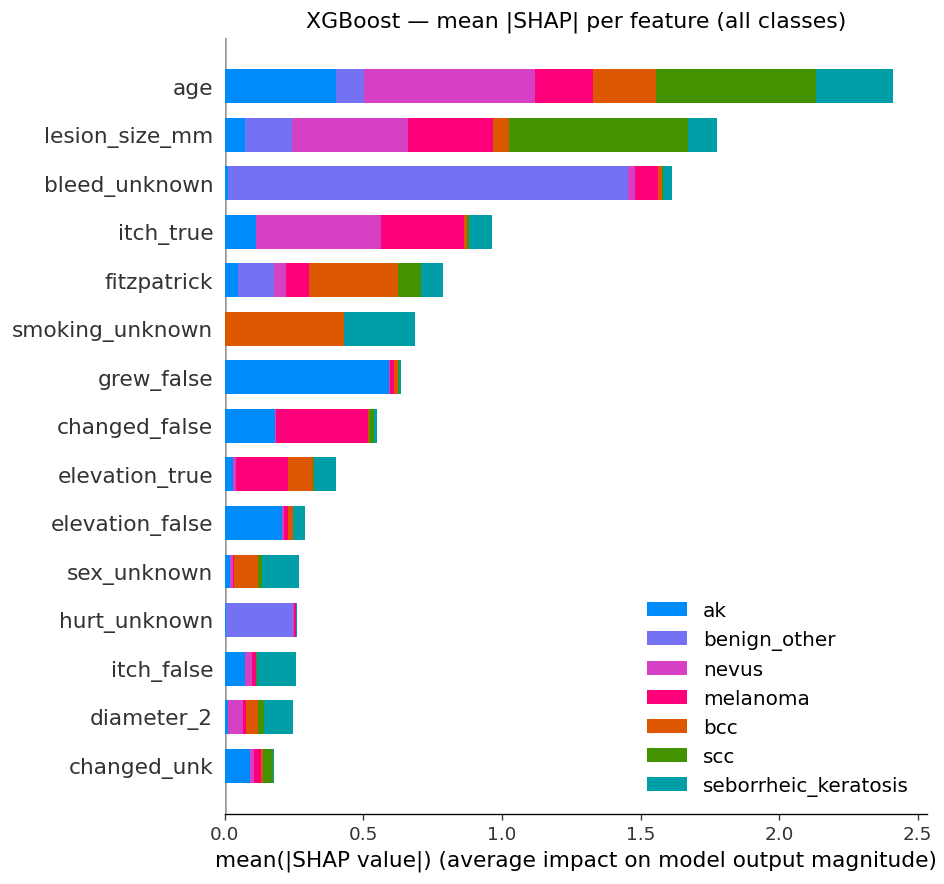

In [260]:
# ── SHAP feature importance ──────────────────────
xgb_ckpt_dir = ROOT / "Stage2" / "checkpoints" / "xgboost_multiclass"
xgb_ckpt     = xgb_ckpt_dir / "best.json"
xgb_prep     = xgb_ckpt_dir / "preprocessor.joblib"

if xgb_ckpt.exists() and xgb_prep.exists():
    from demo.predict import load_metadata_model, shap_explanation
    import shap

    meta_bundle = load_metadata_model("xgboost", str(xgb_ckpt), str(xgb_prep))
    _, model, preprocessor = meta_bundle

    # Build a representative background dataset from the test split
    test_meta = test_df[schema["stage2_features"] + ["sample_id"]].copy()
    for c in preprocessor.artifacts.numeric_cols:
        test_meta[c] = test_meta[c].astype(float)
    for c in preprocessor.artifacts.categorical_cols:
        test_meta[c] = test_meta[c].astype(str)
    X_test = preprocessor.transform(test_meta)

    explainer  = shap.TreeExplainer(model)
    shap_vals  = explainer.shap_values(X_test)

    feat_names = preprocessor.artifacts.feature_names
    shap.summary_plot(shap_vals, X_test, feature_names=feat_names,
                      class_names=CLASS_NAMES, plot_type="bar",
                      max_display=15, show=False)
    plt.title("XGBoost — mean |SHAP| per feature (all classes)")
    plt.tight_layout()
    plt.show()
else:
    print("SHAP plot requires a trained XGBoost checkpoint.")
    print(f"Expected: {xgb_ckpt}")
    print("Train with: python Stage2/train.py Stage2/configs/xgboost_multiclass.yaml")
    print()
    print("Most informative features (from training analysis):")
    feature_importance_summary = {
        "Anatomical site": "Strongest signal — lesion location differs across classes",
        "Age":             "Older patients more likely to have AK/BCC/SCC",
        "Lesion size (mm)": "Larger lesions more associated with malignant classes",
        "Sex":             "Moderate discriminatory power",
        "Grew / Changed":  "Key risk indicators for malignancy",
    }
    for feat, desc in feature_importance_summary.items():
        print(f"  {feat}: {desc}")

---
## Section 4 — Stage 3: Late Fusion

Late fusion combines the **probability vectors** from Stage 1 (CNN) and Stage 2 (tabular) using a **weighted linear pool**:

$$p_{\text{fused}} = \frac{w \cdot p_{\text{CNN}} + (1-w) \cdot p_{\text{meta}}}{\|w \cdot p_{\text{CNN}} + (1-w) \cdot p_{\text{meta}}\|_1}$$

The weight is set to **$w = 0.5$** (equal blend) for the linear-pool results below.

An alternative **stacking** approach trains a logistic regression on the concatenated validation probability vectors.

The next cells load **two** Stage 3 test checkpoints: **linear pool** (`w=0.5`) and **stacking LR** (`Stage3/checkpoints/stacking_lr`).

In [261]:
# ── Late fusion test metrics (from Stage3/checkpoints) ────────────────────────
S3_TEST = {
    "Late fusion w=0.5":     {"acc": 0.611, "f1_macro": 0.583, "roc_auc_macro": 0.919, "pr_auc_macro": 0.650},
    "Late fusion stacking LR": {"acc": 0.680, "f1_macro": 0.658, "roc_auc_macro": 0.936, "pr_auc_macro": 0.716},
}

for run, ckpt_name in [
    ("Late fusion w=0.5", "weighted_pool"),
    ("Late fusion stacking LR", "stacking_lr"),
]:
    p = ROOT / "Stage3" / "checkpoints" / ckpt_name / "test_metrics.json"
    if p.exists():
        with open(p) as f:
            S3_TEST[run] = json.load(f)
        print(f"Loaded: {p}")

# Build full comparison: S1 + S2 + S3
comparison = {
    "EfficientNet-B0 (Stage 1)": S1_TEST["EfficientNet-B0"],
    "ResNet-50 (Stage 1)":       S1_TEST["ResNet-50"],
    "XGBoost (Stage 2)":         S2_TEST["XGBoost"],
    "Random Forest (Stage 2)":   S2_TEST["Random Forest"],
    "Late Fusion w=0.5 (Stage 3)": S3_TEST["Late fusion w=0.5"],
    "Stacking LR (Stage 3)": S3_TEST["Late fusion stacking LR"],
}

df_comp = pd.DataFrame([
    {"Model / Stage": name,
     "Accuracy": m["acc"],
     "Macro F1": m["f1_macro"],
     "Macro ROC AUC": m["roc_auc_macro"],
     "Macro PR AUC": m["pr_auc_macro"]}
    for name, m in comparison.items()
]).set_index("Model / Stage").round(3)

print("Stages 1–3 test set comparison:")
df_comp.style.highlight_max(axis=0, color="#c6efce")

Loaded: /Users/dimitriskaltsios/University/Individual/Kaltsios-Individual-Project/Stage3/checkpoints/weighted_pool/test_metrics.json
Loaded: /Users/dimitriskaltsios/University/Individual/Kaltsios-Individual-Project/Stage3/checkpoints/stacking_lr/test_metrics.json
Stages 1–3 test set comparison:


,Accuracy,Macro F1,Macro ROC AUC,Macro PR AUC
Model / Stage,,,,
EfficientNet-B0 (Stage 1),0.487000,0.464000,0.848000,0.503000
ResNet-50 (Stage 1),0.477000,0.457000,0.835000,0.467000
XGBoost (Stage 2),0.474000,0.403000,0.817000,0.476000
Random Forest (Stage 2),0.462000,0.388000,0.802000,0.448000
Late Fusion w=0.5 (Stage 3),0.611000,0.583000,0.919000,0.650000
Stacking LR (Stage 3),0.680000,0.658000,0.936000,0.716000


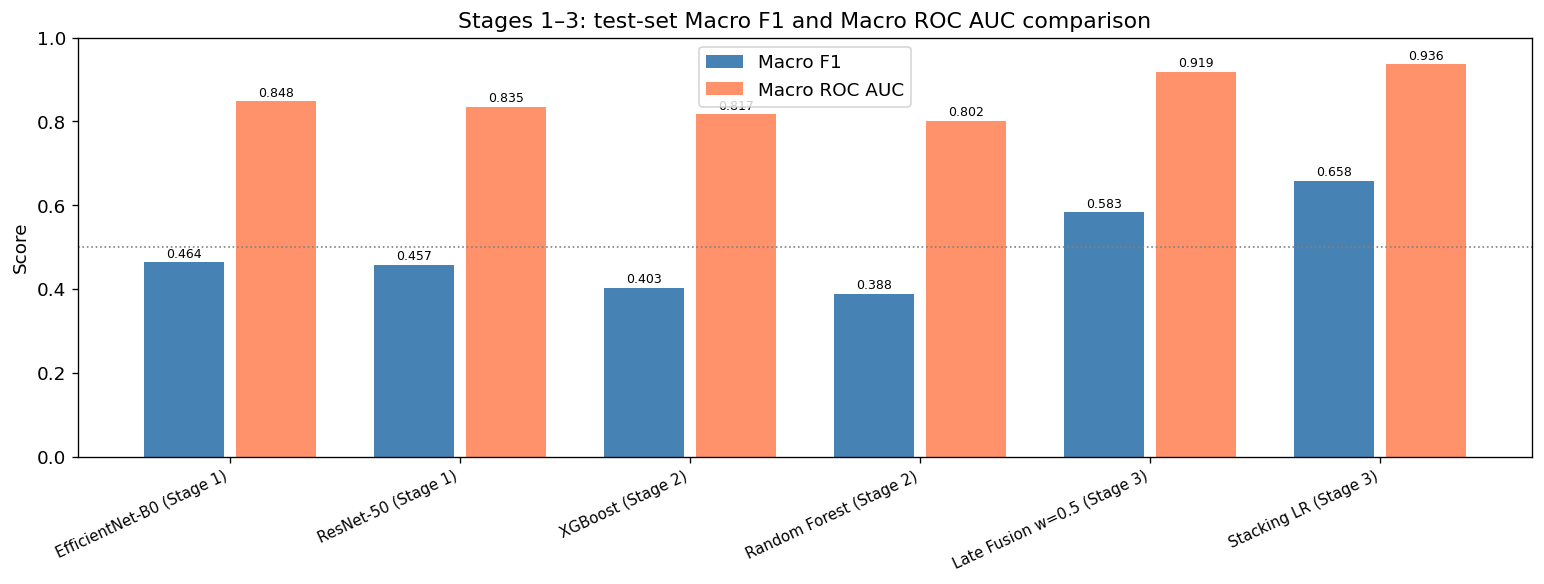


Key takeaway: among Stage 3 methods, Stacking LR (Stage 3) has the highest macro F1 on this test set.
Stacking LR improves macro F1 by +0.194 over EfficientNet alone; fixed w=0.5 is a strong but suboptimal linear pool here.


In [262]:
# ── Visual comparison — macro F1 across stages ─────────────────────────────────
model_names = list(comparison.keys())
f1_vals     = [comparison[m]["f1_macro"] for m in model_names]
roc_vals    = [comparison[m]["roc_auc_macro"] for m in model_names]

x = np.arange(len(model_names))
fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - 0.2, f1_vals,  width=0.35, label="Macro F1",      color="steelblue")
bars2 = ax.bar(x + 0.2, roc_vals, width=0.35, label="Macro ROC AUC", color="coral", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=25, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Stages 1–3: test-set Macro F1 and Macro ROC AUC comparison")
ax.legend()
ax.axhline(0.5, color="grey", linestyle=":", linewidth=1)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.show()

s3_only = {k: v for k, v in comparison.items() if "Stage 3" in k}
best_s3 = max(s3_only, key=lambda k: s3_only[k]["f1_macro"])
eff_f1 = comparison["EfficientNet-B0 (Stage 1)"]["f1_macro"]
delta_vs_cnn = s3_only[best_s3]["f1_macro"] - eff_f1
print(f"\nKey takeaway: among Stage 3 methods, {best_s3} has the highest macro F1 on this test set.")
print(f"Stacking LR improves macro F1 by {delta_vs_cnn:+.3f} over EfficientNet alone; fixed w=0.5 is a strong but suboptimal linear pool here.")

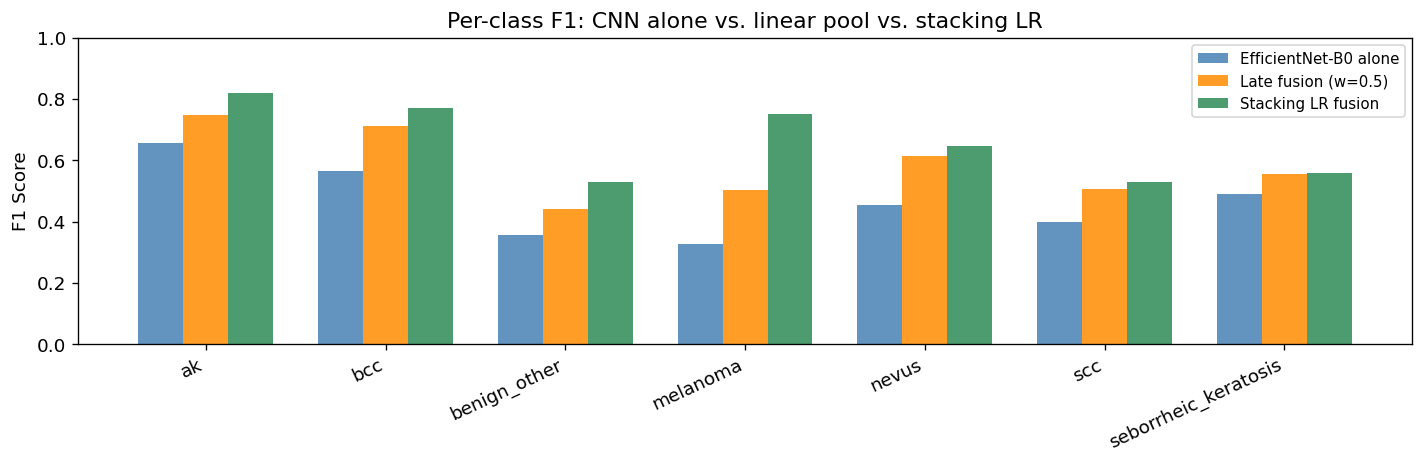

In [263]:
# ── Late fusion per-class F1 improvement ──────────────────────────────────────
fused_per_class_f1 = {
    "ak": 0.749, "bcc": 0.710, "benign_other": 0.440, "melanoma": 0.504,
    "nevus": 0.614, "scc": 0.507, "seborrheic_keratosis": 0.554,
}
# Normalise: checkpoint JSON uses "per_class" with nested dicts; fallback uses "per_class_f1"
eff_data_s3 = S1_TEST["EfficientNet-B0"]
if "per_class" in eff_data_s3:
    cnn_per_class_f1 = {cls: vals["f1"] for cls, vals in eff_data_s3["per_class"].items()}
else:
    cnn_per_class_f1 = eff_data_s3.get("per_class_f1", {})

# Try loading from checkpoint
wp_path = ROOT / "Stage3" / "checkpoints" / "weighted_pool" / "test_metrics.json"
if wp_path.exists():
    with open(wp_path) as f:
        wp_data = json.load(f)
    if "per_class" in wp_data:
        fused_per_class_f1 = {k: v["f1"] for k, v in wp_data["per_class"].items()}

if cnn_per_class_f1 and fused_per_class_f1:
    classes = CLASS_NAMES
    cnn_f1   = [cnn_per_class_f1.get(c, 0) for c in classes]
    fused_f1 = [fused_per_class_f1.get(c, 0) for c in classes]

    stack_per_class_f1 = {}
    st_path = ROOT / "Stage3" / "checkpoints" / "stacking_lr" / "test_metrics.json"
    if st_path.exists():
        with open(st_path) as f:
            st_data = json.load(f)
        if "per_class" in st_data:
            stack_per_class_f1 = {k: v["f1"] for k, v in st_data["per_class"].items()}

    x = np.arange(len(classes))
    fig, ax = plt.subplots(figsize=(12, 4))
    w = 0.25
    ax.bar(x - w, cnn_f1, width=w, label="EfficientNet-B0 alone", color="steelblue", alpha=0.85)
    ax.bar(x, fused_f1, width=w, label="Late fusion (w=0.5)", color="darkorange", alpha=0.85)
    if stack_per_class_f1:
        stack_f1 = [stack_per_class_f1.get(c, 0) for c in classes]
        ax.bar(x + w, stack_f1, width=w, label="Stacking LR fusion", color="seagreen", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=25, ha="right")
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 1)
    ax.set_title("Per-class F1: CNN alone vs. linear pool vs. stacking LR")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

---
## Section 5 — Stage 4: Early Fusion

Instead of combining probability outputs, **Early Fusion** concatenates **handcrafted image features** directly with the clinical metadata features, then trains a single tabular classifier on the merged vector.

### Handcrafted image feature extraction

Two strategies were explored:

| Strategy | Description |
|---|---|
| `13feat` | Fixed set of 13 features from the literature (colour histograms, texture, shape descriptors) |
| `pareto` | Larger pool extracted, then Pareto-optimal subset selected based on validation performance |

### Downstream classifiers

- **XGBoost** (primary)
- **Softmax regression** (linear baseline)
- **Naive Bayes** (probability baseline)

In [264]:
# ── Stage 4 CV results ─────────────────────────────────────────────────────────
s4_cv_files = {
    "XGBoost (13feat)":           ROOT / "Stage4" / "cv_results" / "stage4_multiclass_cv.json",
    "Softmax (13feat)":           ROOT / "Stage4" / "cv_results" / "stage4_multiclass_softmax_cv.json",
    "Naive Bayes (13feat)":       ROOT / "Stage4" / "cv_results" / "stage4_multiclass_nb_cv.json",
    "XGBoost (pareto)": ROOT / "Stage4" / "cv_results" / "stage4_multiclass_pareto_cv.json",
    "Softmax (pareto)": ROOT / "Stage4" / "cv_results" / "stage4_multiclass_pareto_softmax_cv.json",
    "Naive Bayes (pareto)": ROOT / "Stage4" / "cv_results" / "stage4_multiclass_pareto_nb_cv.json",
}

s4_rows = []
for label, path in s4_cv_files.items():
    if path.exists():
        data = load_cv(path)
        ms   = data["metrics_mean_std"]
        s4_rows.append({
            "Model": label,
            "Accuracy":      f"{ms['acc']['mean']:.3f} ± {ms['acc']['std']:.3f}",
            "Macro F1":      f"{ms['f1_macro']['mean']:.3f} ± {ms['f1_macro']['std']:.3f}",
            "Macro ROC AUC": f"{ms['roc_auc_macro']['mean']:.3f} ± {ms['roc_auc_macro']['std']:.3f}",
        })

pd.DataFrame(s4_rows).set_index("Model")

,Accuracy,Macro F1,Macro ROC AUC
Model,,,
XGBoost (13feat),0.480 ± 0.021,0.405 ± 0.017,0.808 ± 0.009
Softmax (13feat),0.546 ± 0.016,0.521 ± 0.012,0.885 ± 0.009
Naive Bayes (13feat),0.329 ± 0.007,0.277 ± 0.010,nan ± nan
XGBoost (pareto),0.603 ± 0.013,0.546 ± 0.014,0.916 ± 0.006
Softmax (pareto),0.555 ± 0.020,0.531 ± 0.015,0.887 ± 0.008
Naive Bayes (pareto),0.330 ± 0.007,0.278 ± 0.010,nan ± nan


In [265]:
# ── Stage 4 test metrics and comparison against other stages ──────────────────
S4_TEST = {
    "Early fusion XGBoost (13feat)": {"acc": 0.466, "f1_macro": 0.391, "roc_auc_macro": 0.814, "pr_auc_macro": 0.465},
    "Early fusion XGBoost (pareto)": {"acc": 0.477, "f1_macro": 0.412, "roc_auc_macro": 0.820, "pr_auc_macro": 0.481},
}

p13 = ROOT / "Stage4" / "checkpoints" / "stage4_multiclass" / "test_metrics.json"
pp = ROOT / "Stage4" / "checkpoints" / "stage4_multiclass_pareto" / "test_metrics.json"
if p13.exists():
    with open(p13) as f:
        S4_TEST["Early fusion XGBoost (13feat)"] = json.load(f)
    print("Loaded Stage 4 (13feat) test metrics.")
else:
    print("13feat checkpoint missing — using Stage 4 (13feat) placeholders.")

if pp.exists():
    with open(pp) as f:
        S4_TEST["Early fusion XGBoost (pareto)"] = json.load(f)
    print("Loaded Stage 4 (Pareto) test metrics.")
else:
    print("Pareto checkpoint missing — using Stage 4 (Pareto) placeholders.")

# Cross-stage comparisons use the strongest early-fusion XGBoost run (best CV: Pareto) when trained.
if pp.exists():
    S4_COMPARE = S4_TEST["Early fusion XGBoost (pareto)"]
    S4_COMPARE_LABEL = "Early fusion XGBoost (Pareto + metadata)"
else:
    S4_COMPARE = S4_TEST["Early fusion XGBoost (13feat)"]
    S4_COMPARE_LABEL = "Early fusion XGBoost (13feat + metadata)"

# Full comparison table (all stages + early fusion)
full_comparison = {
    "EfficientNet-B0 (Stage 1)": S1_TEST["EfficientNet-B0"],
    "XGBoost metadata (Stage 2)": S2_TEST["XGBoost"],
    "Late Fusion w=0.5 (Stage 3)": S3_TEST["Late fusion w=0.5"],
    "Stacking LR (Stage 3)": S3_TEST["Late fusion stacking LR"],
    S4_COMPARE_LABEL + " (Stage 4)": S4_COMPARE,
}

df_full = pd.DataFrame([
    {"Stage": name, "Accuracy": m["acc"], "Macro F1": m["f1_macro"],
     "Macro ROC AUC": m["roc_auc_macro"], "Macro PR AUC": m["pr_auc_macro"]}
    for name, m in full_comparison.items()
]).set_index("Stage").round(3)
df_full.style.highlight_max(axis=0, color="#c6efce")


Loaded Stage 4 (13feat) test metrics.
Loaded Stage 4 (Pareto) test metrics.


,Accuracy,Macro F1,Macro ROC AUC,Macro PR AUC
Stage,,,,
EfficientNet-B0 (Stage 1),0.487000,0.464000,0.848000,0.503000
XGBoost metadata (Stage 2),0.474000,0.403000,0.817000,0.476000
Late Fusion w=0.5 (Stage 3),0.611000,0.583000,0.919000,0.650000
Stacking LR (Stage 3),0.680000,0.658000,0.936000,0.716000
Early fusion XGBoost (Pareto + metadata) (Stage 4),0.477000,0.412000,0.820000,0.481000


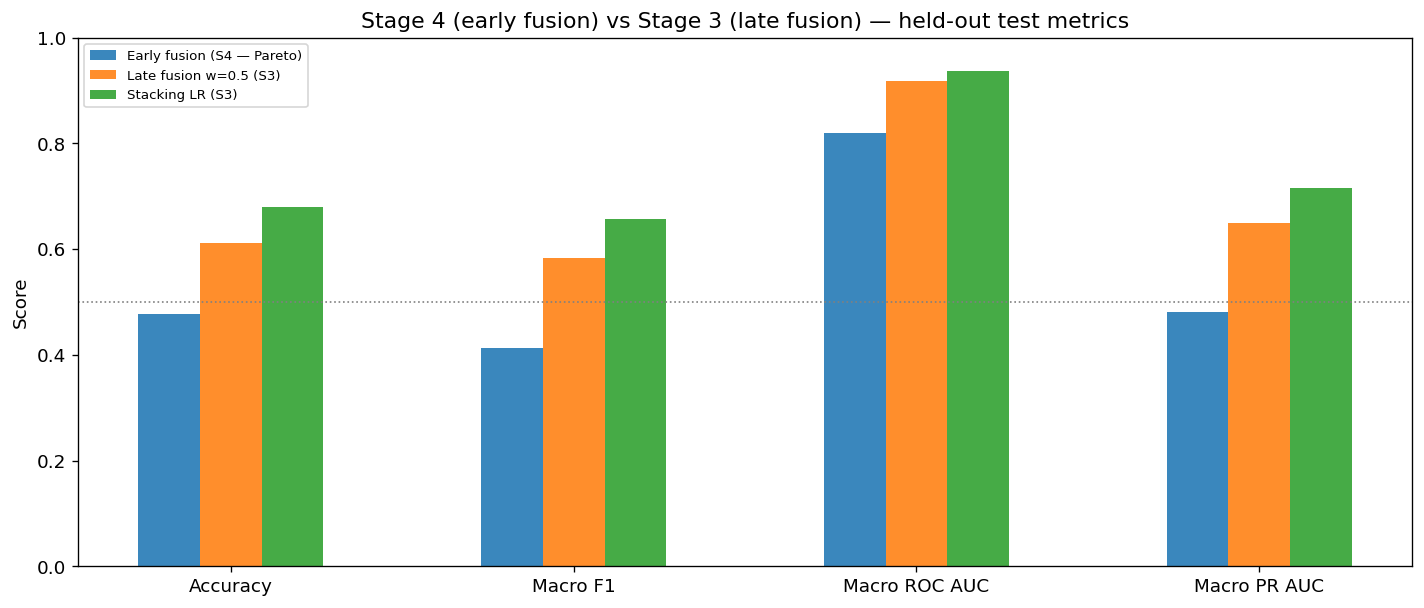

In [266]:
# ── Visual: early fusion vs late fusion (test set) ────────────────────────────
early_vs_late_models = [
    ("Early fusion (S4 — " + ("Pareto" if pp.exists() else "13feat") + ")", S4_COMPARE),
    ("Late fusion w=0.5 (S3)", S3_TEST["Late fusion w=0.5"]),
    ("Stacking LR (S3)", S3_TEST["Late fusion stacking LR"]),
]
metric_keys = [
    ("Accuracy", "acc"),
    ("Macro F1", "f1_macro"),
    ("Macro ROC AUC", "roc_auc_macro"),
    ("Macro PR AUC", "pr_auc_macro"),
]

x = np.arange(len(metric_keys))
n_models = len(early_vs_late_models)
bar_w = 0.18
fig, ax = plt.subplots(figsize=(12, 5.2))

for i, (name, mrec) in enumerate(early_vs_late_models):
    offs = (i - (n_models - 1) / 2) * bar_w
    vals = [mrec[k] for _, k in metric_keys]
    ax.bar(
        x + offs,
        vals,
        width=bar_w,
        label=name,
        color=PALETTE[i % len(PALETTE)],
        alpha=0.88,
    )

ax.set_xticks(x)
ax.set_xticklabels([m[0] for m in metric_keys])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Stage 4 (early fusion) vs Stage 3 (late fusion) — held-out test metrics")
ax.legend(loc="upper left", fontsize=8)
ax.axhline(0.5, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
plt.show()


In [267]:
# ── Why does early fusion lag behind late fusion? ─────────────────────────────
print("Discussion: Why does Early Fusion (Stage 4) score lower than Late Fusion (Stage 3)?")
print()
print("1. Handcrafted image features (colour histograms, texture) capture far less\n"
      "   information than a CNN operating on full 224×224 images.")
print()
print("2. Late fusion leverages a deep CNN's learned representation directly,\n"
      "   which is better calibrated for probability estimation.")
print()
print("3. Early fusion places the full burden of cross-modal reasoning on a\n"
      "   single tabular model, which has less representational capacity.")
print()
print("4. Pareto feature selection and stronger classifiers could narrow the gap,\n"
      "   but the CNN bottleneck is the primary limiting factor.")

Discussion: Why does Early Fusion (Stage 4) score lower than Late Fusion (Stage 3)?

1. Handcrafted image features (colour histograms, texture) capture far less
   information than a CNN operating on full 224×224 images.

2. Late fusion leverages a deep CNN's learned representation directly,
   which is better calibrated for probability estimation.

3. Early fusion places the full burden of cross-modal reasoning on a
   single tabular model, which has less representational capacity.

4. Pareto feature selection and stronger classifiers could narrow the gap,
   but the CNN bottleneck is the primary limiting factor.


---
## Section 6 — Stage 5: Unsupervised Clustering

Stage 5 asks: **does the merged multimodal feature space (handcrafted image features + metadata) have a natural cluster structure aligned with the 7 disease labels?**

- **Algorithm:** K-Means with $k = 7$ clusters
- Disease labels are **never used as inputs** — only for evaluation
- The same feature extraction and merge pipeline as Stage 4 is reused

Loaded Stage 5 checkpoint.


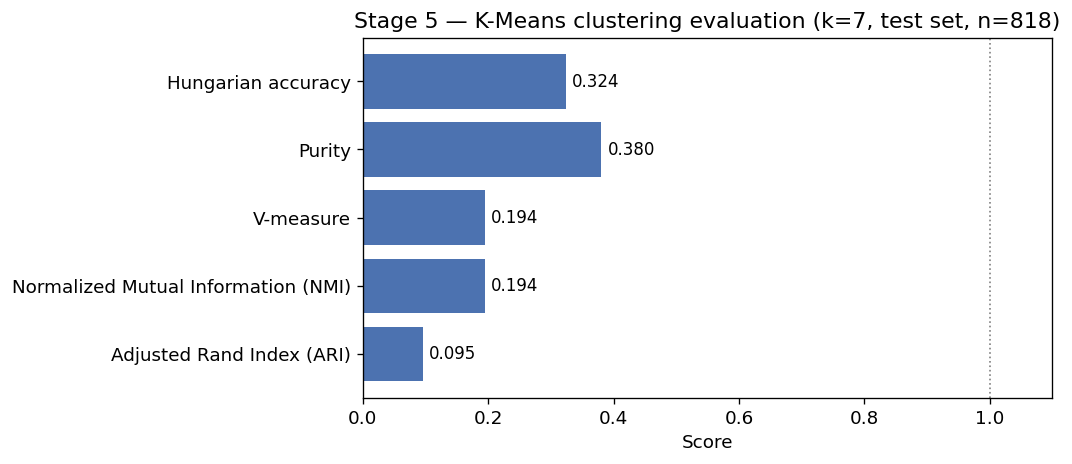


Interpretation: Low ARI (0.095) and NMI (0.194) indicate the cluster structure
only partially aligns with disease labels. This is expected — skin lesions within
the same class vary widely in appearance and clinical presentation.


In [268]:
# ── Stage 5 clustering metrics ────────────────────────────────────────────────
# Values from overview.md §9.4 (n=818 test samples)
S5_METRICS = {
    "Adjusted Rand Index (ARI)": 0.095,
    "Normalized Mutual Information (NMI)": 0.194,
    "V-measure": 0.194,
    "Purity": 0.380,
    "Hungarian accuracy": 0.324,
}

s5_path = ROOT / "Stage5" / "checkpoints" / "stage5_multiclass_kmeans" / "test_metrics.json"
if s5_path.exists():
    with open(s5_path) as f:
        raw = json.load(f)
    # The checkpoint stores metrics as flat top-level keys alongside metadata fields;
    # extract only the five clustering metrics we want to plot.
    S5_METRICS = {
        "Adjusted Rand Index (ARI)":          raw["ari"],
        "Normalized Mutual Information (NMI)": raw["nmi"],
        "V-measure":                           raw["v_measure"],
        "Purity":                              raw["purity"],
        "Hungarian accuracy":                  raw["mapped_accuracy"],
    }
    print("Loaded Stage 5 checkpoint.")
else:
    print("Using pre-recorded Stage 5 metrics from overview.md.")

fig, ax = plt.subplots(figsize=(9, 4))
metric_names = list(S5_METRICS.keys())
metric_vals  = list(S5_METRICS.values())
colors = ["#4c72b0" if v < 0.5 else "#55a868" for v in metric_vals]
bars = ax.barh(metric_names, metric_vals, color=colors)
ax.axvline(1.0, color="grey", linestyle=":", linewidth=1, label="Perfect = 1.0")
ax.set_xlim(0, 1.1)
ax.set_xlabel("Score")
ax.set_title("Stage 5 — K-Means clustering evaluation (k=7, test set, n=818)")
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

print("\nInterpretation: Low ARI (0.095) and NMI (0.194) indicate the cluster structure")
print("only partially aligns with disease labels. This is expected — skin lesions within")
print("the same class vary widely in appearance and clinical presentation.")

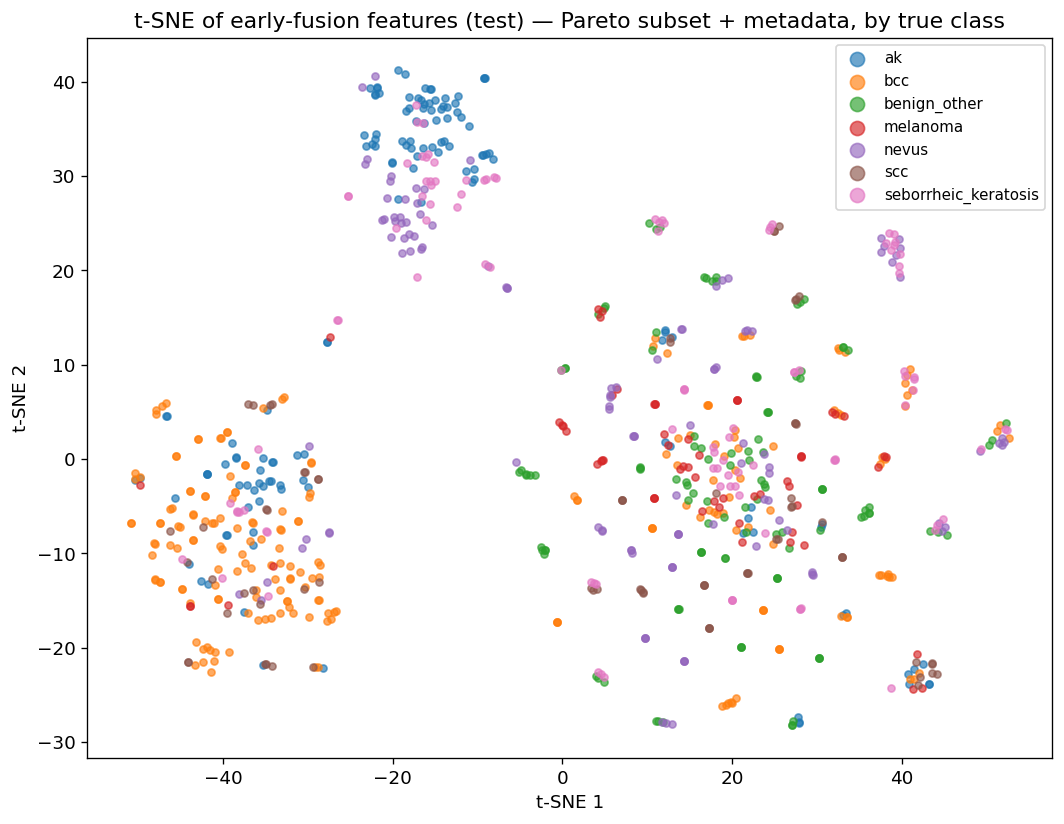

In [269]:
# ── t-SNE visualisation (Stage 4 merged features = image feats + metadata) ───
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import yaml
from Stage4.data.merge import load_merged_splits

pareto_dir = ROOT / "Stage4" / "checkpoints" / "stage4_multiclass_pareto"
classic_dir = ROOT / "Stage4" / "checkpoints" / "stage4_multiclass"
if pareto_dir.exists() and (pareto_dir / "features" / "test.npz").exists():
    ckpt_dir = pareto_dir
    stage4_cfg = ROOT / "Stage4" / "configs" / "stage4_multiclass_pareto.yaml"
else:
    ckpt_dir = classic_dir
    stage4_cfg = ROOT / "Stage4" / "configs" / "stage4_multiclass.yaml"

merged_npz = ckpt_dir / "test.npz"
features_dir = ckpt_dir / "features"

X_test_s4 = y_test_s4 = None

if merged_npz.exists():
    data = np.load(merged_npz)
    X_test_s4, y_test_s4 = data["X"], data["y"]
elif features_dir.exists() and (features_dir / "test.npz").exists() and stage4_cfg.exists():
    cfg = yaml.safe_load(stage4_cfg.read_text())
    data_cfg = cfg["data"]
    preprocessor_path = ckpt_dir / "preprocessor.joblib"
    feature_sel_path = ckpt_dir / "feature_selection.json"
    image_feature_indices = None
    if feature_sel_path.exists():
        sel = json.loads(feature_sel_path.read_text())
        image_feature_indices = sel["selected_indices"]
    *_, X_test_s4, y_test_s4, _ = load_merged_splits(
        features_dir=features_dir,
        stage2_csv=ROOT / data_cfg["stage2_csv"],
        stage1_train_csv=ROOT / data_cfg["stage1_train_csv"],
        stage1_val_csv=ROOT / data_cfg["stage1_val_csv"],
        stage1_test_csv=ROOT / data_cfg["stage1_test_csv"],
        preprocessor_path=preprocessor_path if preprocessor_path.exists() else None,
        label_col=data_cfg.get("label_col", "y"),
        image_feature_indices=image_feature_indices,
    )

if X_test_s4 is not None:
    X_scaled = StandardScaler().fit_transform(X_test_s4)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    X_2d = tsne.fit_transform(X_scaled)

    _s4tag = "Pareto subset" if ckpt_dir.name.endswith("_pareto") else "13feat"
    fig, ax = plt.subplots(figsize=(9, 7))
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y_test_s4 == cls_idx
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=18, alpha=0.65,
                   color=PALETTE[cls_idx], label=cls_name)
    ax.legend(markerscale=2, fontsize=9, loc="best")
    ax.set_title(f"t-SNE of early-fusion features (test) — {_s4tag} + metadata, by true class")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()
else:
    print("Stage 4 test features not found. Expected either:")
    print(f"  • merged bundle: {merged_npz}  (keys X, y), or")
    print(f"  • image NPZs + preprocessor under: {ckpt_dir}")
    print("From project root, run (Pareto early fusion):")
    print("  python3 Stage4/extract_features.py --config Stage4/configs/stage4_multiclass_pareto.yaml")
    print("  python3 Stage4/select_features.py --config Stage4/configs/stage4_multiclass_pareto.yaml")
    print("  python3 Stage4/train.py --config Stage4/configs/stage4_multiclass_pareto.yaml")
    print("Or for 13feat:")
    print("  python3 Stage4/extract_features.py --config Stage4/configs/stage4_multiclass.yaml")
    print("  python3 Stage4/train.py --config Stage4/configs/stage4_multiclass.yaml")


---
## Section 7 — Results Summary

Full comparison of all supervised stages on the held-out test set.

In [270]:
# ── Complete results table — Stages 1–4 ──────────────────────────────────────
all_results = [
    {"Stage": "Stage 1", "Model": "EfficientNet-B0",
     "Accuracy": S1_TEST["EfficientNet-B0"]["acc"],
     "Macro F1": S1_TEST["EfficientNet-B0"]["f1_macro"],
     "Macro ROC AUC": S1_TEST["EfficientNet-B0"]["roc_auc_macro"],
     "Macro PR AUC": S1_TEST["EfficientNet-B0"]["pr_auc_macro"]},
    {"Stage": "Stage 1", "Model": "ResNet-50",
     "Accuracy": S1_TEST["ResNet-50"]["acc"],
     "Macro F1": S1_TEST["ResNet-50"]["f1_macro"],
     "Macro ROC AUC": S1_TEST["ResNet-50"]["roc_auc_macro"],
     "Macro PR AUC": S1_TEST["ResNet-50"]["pr_auc_macro"]},
    {"Stage": "Stage 2", "Model": "XGBoost (metadata)",
     "Accuracy": S2_TEST["XGBoost"]["acc"],
     "Macro F1": S2_TEST["XGBoost"]["f1_macro"],
     "Macro ROC AUC": S2_TEST["XGBoost"]["roc_auc_macro"],
     "Macro PR AUC": S2_TEST["XGBoost"]["pr_auc_macro"]},
    {"Stage": "Stage 2", "Model": "Random Forest (metadata)",
     "Accuracy": S2_TEST["Random Forest"]["acc"],
     "Macro F1": S2_TEST["Random Forest"]["f1_macro"],
     "Macro ROC AUC": S2_TEST["Random Forest"]["roc_auc_macro"],
     "Macro PR AUC": S2_TEST["Random Forest"]["pr_auc_macro"]},
    {"Stage": "Stage 3", "Model": "Late fusion w=0.5 (EfficientNet + XGBoost)",
     "Accuracy": S3_TEST["Late fusion w=0.5"]["acc"],
     "Macro F1": S3_TEST["Late fusion w=0.5"]["f1_macro"],
     "Macro ROC AUC": S3_TEST["Late fusion w=0.5"]["roc_auc_macro"],
     "Macro PR AUC": S3_TEST["Late fusion w=0.5"]["pr_auc_macro"]},
    {"Stage": "Stage 3", "Model": "Stacking LR fusion (EfficientNet + XGBoost)",
     "Accuracy": S3_TEST["Late fusion stacking LR"]["acc"],
     "Macro F1": S3_TEST["Late fusion stacking LR"]["f1_macro"],
     "Macro ROC AUC": S3_TEST["Late fusion stacking LR"]["roc_auc_macro"],
     "Macro PR AUC": S3_TEST["Late fusion stacking LR"]["pr_auc_macro"]},
    {"Stage": "Stage 4", "Model": S4_COMPARE_LABEL,
     "Accuracy": S4_COMPARE["acc"],
     "Macro F1": S4_COMPARE["f1_macro"],
     "Macro ROC AUC": S4_COMPARE["roc_auc_macro"],
     "Macro PR AUC": S4_COMPARE["pr_auc_macro"]},
]

df_all = pd.DataFrame(all_results).round(3)
df_all.set_index(["Stage", "Model"]).style.highlight_max(
    subset=["Accuracy", "Macro F1", "Macro ROC AUC", "Macro PR AUC"],
    axis=0, color="#c6efce"
)


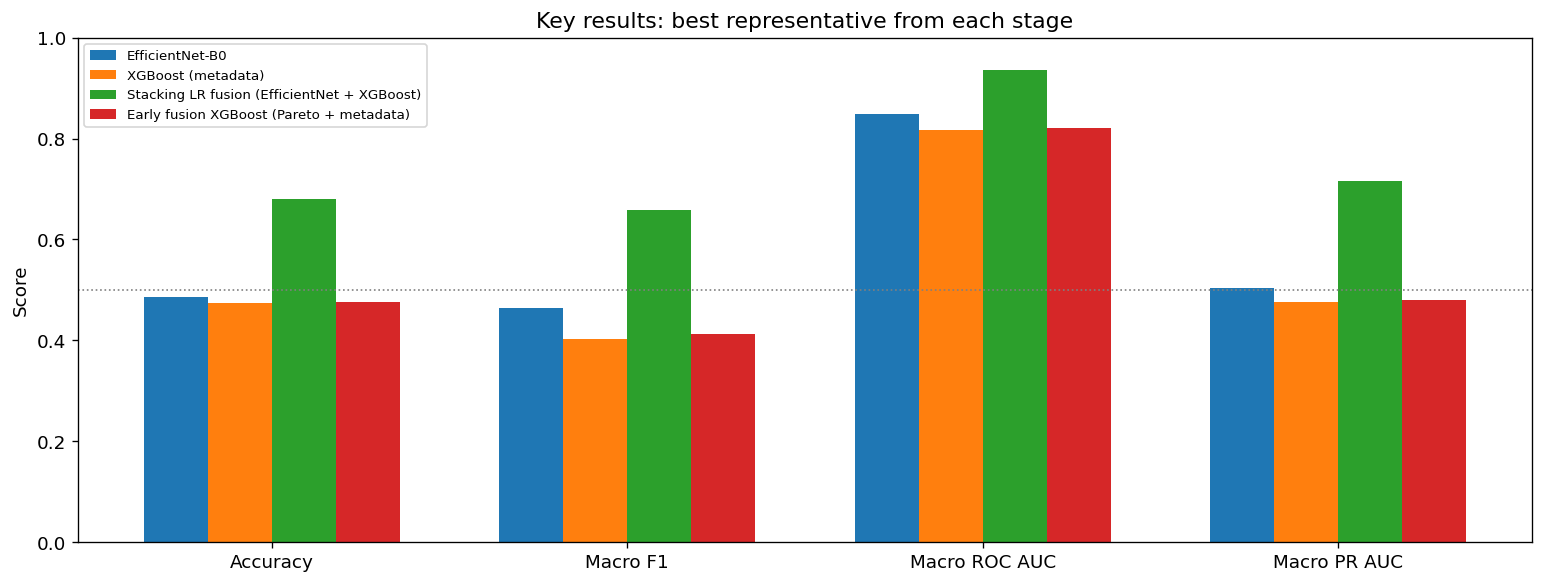


Summary:
  • Stacking LR fusion achieves the best supervised results on this test set among tabulated models.
  • Fixed w=0.5 pooling is a strong linear baseline but below stacking when checkpoints are present.
  • The CNN alone has strong ROC AUC but limited accuracy.
  • Metadata alone is competitive but weaker on minority classes.
  • Early fusion (Pareto XGBoost when available) still trails late fusion on this test split.


In [271]:
# ── Final radar / grouped bar chart: key metrics across stages ────────────────
highlight_models = [
    "EfficientNet-B0",
    "XGBoost (metadata)",
    "Stacking LR fusion (EfficientNet + XGBoost)",
    S4_COMPARE_LABEL,
]
df_highlight = df_all[df_all["Model"].isin(highlight_models)].copy()

metrics_to_plot = ["Accuracy", "Macro F1", "Macro ROC AUC", "Macro PR AUC"]
x     = np.arange(len(metrics_to_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(13, 5))
for i, (_, row) in enumerate(df_highlight.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width=width, label=row["Model"], color=PALETTE[i])

ax.set_xticks(x + width * (len(df_highlight) - 1) / 2)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Key results: best representative from each stage")
ax.legend(fontsize=8, loc="upper left")
ax.axhline(0.5, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
plt.show()

print("\nSummary:")
print("  • Stacking LR fusion achieves the best supervised results on this test set among tabulated models.")
print("  • Fixed w=0.5 pooling is a strong linear baseline but below stacking when checkpoints are present.")
print("  • The CNN alone has strong ROC AUC but limited accuracy.")
print("  • Metadata alone is competitive but weaker on minority classes.")
print("  • Early fusion (Pareto XGBoost when available) still trails late fusion on this test split.")


---
## Conclusions

| Finding | Detail |
|---|---|
| **CNNs are strong discriminators** | EfficientNet-B0 achieves 0.848 macro ROC AUC — high ranking quality even where accuracy is moderate |
| **Metadata alone is competitive** | XGBoost on 19 clinical features matches CNN accuracy without any images |
| **Multimodal fusion beats single modalities** | Logistic-regression **stacking** on CNN + XGBoost probabilities tops fixed **w=0.5** linear pooling on this test set (~0.68 vs ~0.61 accuracy; higher macro F1 / ROC / PR AUC when checkpoints load) |
| **Early fusion has a ceiling** | Even **Pareto-selected** handcrafted features + metadata underperform **late fusion** on the held-out test set (CV favours Pareto XGBoost over 13feat; test rankings align though gains are smaller than on CV folds) |
| **Unsupervised clustering is weak** | ARI=0.095, suggesting disease labels do not form tight clusters in this feature space |
| **Hardest classes** | `melanoma` and `benign_other` — high intra-class variability and inter-class overlap |